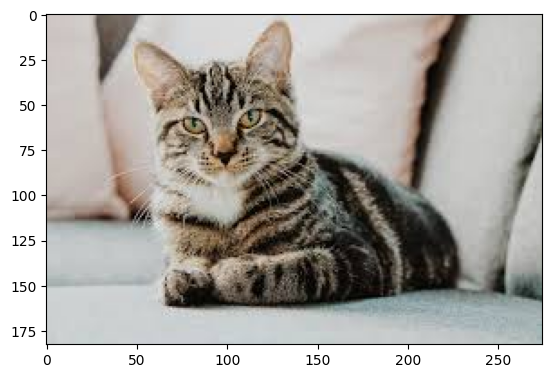

In [5]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('cat.jpg')
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()

In [6]:
# VGG Model 사용
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array

model = VGG16(weights='imagenet')

image = cv2.resize(image, (224, 224))
image = img_to_array(image)
image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
image = preprocess_input(image)

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [7]:
# Prediction
from tensorflow.keras.applications.vgg16 import decode_predictions

yhat = model.predict(image)
label = decode_predictions(yhat)
label = label[0][0]

print(label[1], label[2])

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
tabby 0.40152147


In [8]:
# Top 5
decode_predictions(yhat)

[[('n02123045', 'tabby', np.float32(0.40152147)),
  ('n02123159', 'tiger_cat', np.float32(0.22902367)),
  ('n02124075', 'Egyptian_cat', np.float32(0.18864611)),
  ('n04040759', 'radiator', np.float32(0.015489062)),
  ('n04522168', 'vase', np.float32(0.014818353))]]

In [ ]:
# Data 준비
import os

path = './train/'
full_names = os.listdir(path)

labels = [name.split('.')[0] for name in full_names]
file_id = [name.split('.')[1] for name in full_names]

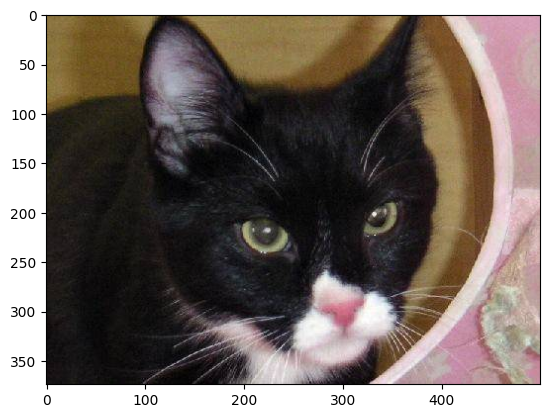

In [14]:
# 데이터 하나 추출
import random
import matplotlib.image as mpimg

image = mpimg.imread(path + full_names[6])
plt.imshow(image)
plt.show()

In [15]:
# 위 이미지 예측
image = cv2.resize(image, dsize=(224, 224))
image = img_to_array(image)
image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
image = preprocess_input(image)

yhat = model.predict(image)
label = decode_predictions(yhat)
label = label[0][0]

print(label[1], label[2])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
bucket 0.1660261


In [16]:
# VGG16 Model 입력을 위한 전처리 함수
def resize_and_preprocess_vgg(image):
    image = cv2.resize(image, dsize=(224, 224))
    image = img_to_array(image)
    image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
    image = preprocess_input(image)
    return image

In [17]:
# VGG16 Model 예측 함수
def predict_vgg(image):
    yhat = model.predict(image)
    label = decode_predictions(yhat)
    return label[0][0][1]

dog.3730.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
cat.706.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
dog.3234.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
dog.11336.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
dog.8222.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
cat.11181.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


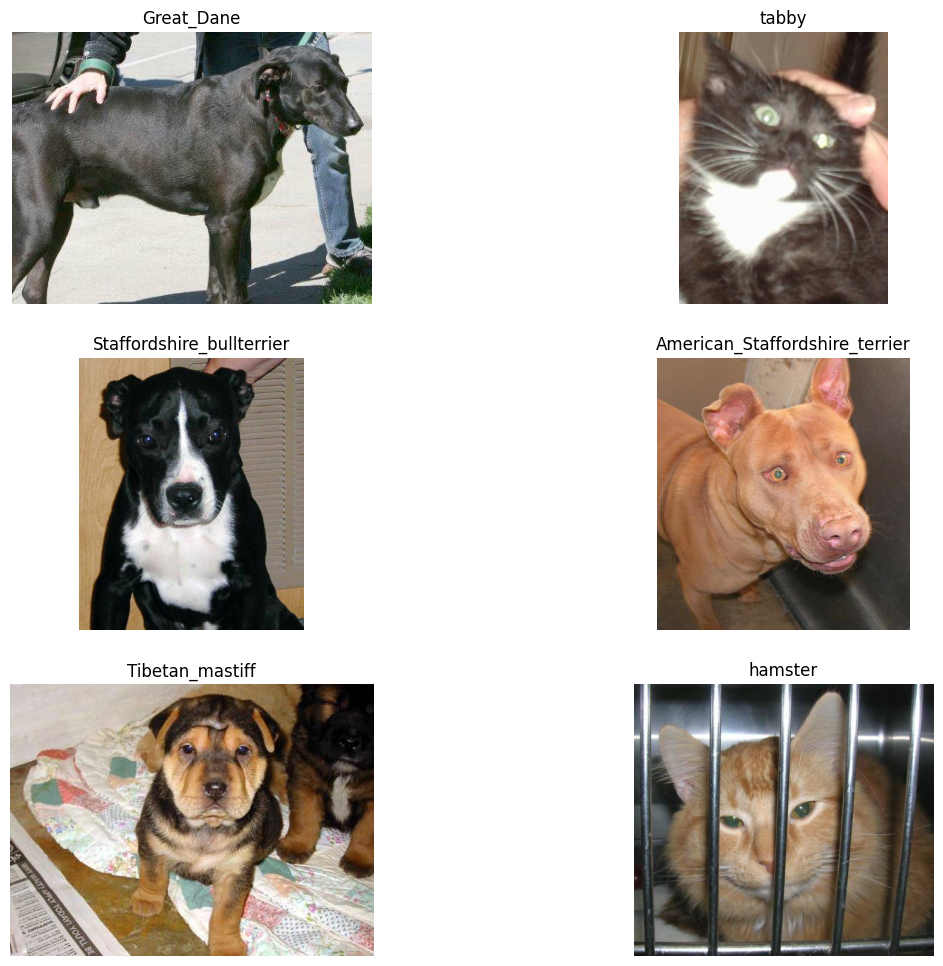

In [18]:
plt.figure(figsize=(14, 12))

idx = 1

for name in random.choices(full_names, k=6):
    image = mpimg.imread(path + name)
    plt.subplot(3, 2, idx)
    plt.imshow(image)
    idx += 1

    image = resize_and_preprocess_vgg(image)
    print(name)

    result = predict_vgg(image)
    plt.title(result)
    plt.axis('off')
plt.show()

In [19]:
# Dogs vs Cats Data
import pandas as pd

train_df = pd.DataFrame({'file': os.listdir('./train')})
train_df.head()

,file
0,cat.0.jpg
1,cat.1.jpg
2,cat.10.jpg
3,cat.100.jpg
4,cat.1000.jpg


In [20]:
train_df['label'] = train_df['file'].apply(lambda x: x.split('.')[0])
train_df.head()

,file,label
0,cat.0.jpg,cat
1,cat.1.jpg,cat
2,cat.10.jpg,cat
3,cat.100.jpg,cat
4,cat.1000.jpg,cat


In [21]:
# Data Split
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(train_df,
                                        test_size=0.2,
                                        stratify=train_df['label'],
                                        random_state=13)

In [22]:
# ImageDataGenerator - Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    preprocessing_function=preprocess_input
)

# Validation Data -> No Augmentation
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [23]:
batch_size = 16

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_data,
    directory='./train',
    x_col='file',
    y_col='label',
    class_mode='categorical',
    target_size=(224, 224),
    batch_size=batch_size,
    seed=13
)

Found 20000 validated image filenames belonging to 2 classes.


In [25]:
val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_data,
    directory='./train',
    x_col='file',
    y_col='label',
    class_mode='categorical',
    target_size=(224, 224),
    batch_size=batch_size,
    shuffle=False, # validation 데이터는 shuffle X
    seed=13
)

Found 5000 validated image filenames belonging to 2 classes.


In [26]:
# Model (CNN Layer만 가져오기)
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [27]:
# CNN Layer는 학습이 되지 않도록 설정
for layer in base_model.layers:
    layer.trainable = False

base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [29]:
# Output Layer 연결
import tensorflow as tf
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense

def vgg16_pretrained():
    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = base_model(inputs)
    x = GlobalAveragePooling2D()(x)
    x = Dense(100, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu')(x)

    outputs = Dense(2, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)

    return model

model = vgg16_pretrained()

model.compile(
    optimizer='adam',
    loss = 'categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        51,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,772,582 (56.35 MB)

 Trainable params: 57,894 (226.15 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [32]:
# Callbacks
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

lr_callback = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.0001
)

es_callback = EarlyStopping(
    monitor='val_loss',
    patience=3
)

cp_callback = ModelCheckpoint(
    monitor='val_accuracy',
    filepath='./vgg_pretrained.weights.h5',
    save_best_only=True,
    save_weights_only=True
)

In [34]:
hist = model.fit(train_generator,
                 epochs=5,
                 validation_data=val_generator,
                 callbacks=[lr_callback, es_callback, cp_callback])

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 457s 357ms/step - accuracy: 0.9110 - loss: 0.3689 - val_accuracy: 0.9816 - val_loss: 0.0466 - learning_rate: 0.0010
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 441s 352ms/step - accuracy: 0.9712 - loss: 0.0770 - val_accuracy: 0.9820 - val_loss: 0.0466 - learning_rate: 0.0010
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 387s 309ms/step - accuracy: 0.9750 - loss: 0.0699 - val_accuracy: 0.9838 - val_loss: 0.0449 - learning_rate: 0.0010
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 375s 300ms/step - accuracy: 0.9762 - loss: 0.0720 - val_accuracy: 0.9836 - val_loss: 0.0407 - learning_rate: 0.0010
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 376s 300ms/step - accuracy: 0.9778 - loss: 0.0598 - val_accuracy: 0.9838 - val_loss: 0.0410 - learning_rate: 0.0010


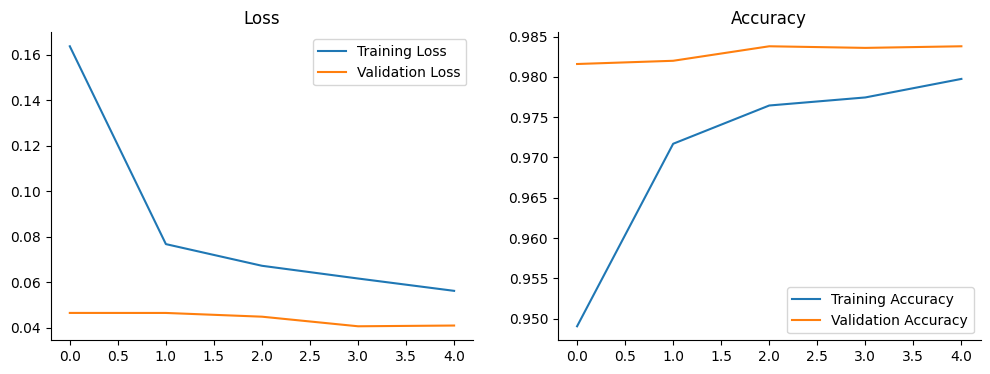

In [35]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(x=range(len(hist.history["loss"])),
             y=hist.history["loss"],
             ax=axes[0],
             label="Training Loss")
sns.lineplot(x=range(len(hist.history["loss"])),
             y=hist.history["val_loss"],
             ax=axes[0],
             label="Validation Loss")

sns.lineplot(x=range(len(hist.history["accuracy"])),
             y=hist.history["accuracy"],
             ax=axes[1],
             label="Training Accuracy")
sns.lineplot(x=range(len(hist.history["accuracy"])),
             y=hist.history["val_accuracy"],
             ax=axes[1],
             label="Validation Accuracy")

axes[0].set_title("Loss"); axes[1].set_title("Accuracy")

sns.despine()
plt.show()

In [36]:
# Evaluate
val_loss, val_acc = model.evaluate(val_generator)
print(f'Validation Loss: {val_loss}, Validation Accuracy: {val_acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9860 - loss: 0.0375
Validation Loss: 0.04104922339320183, Validation Accuracy: 0.9837999939918518


In [37]:
# Prediction
pred = model.predict(val_generator)

313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 121ms/step


In [38]:
train_generator.class_indices

{'cat': 0, 'dog': 1}

In [39]:
# 실제값과 예측값 비교
import numpy as np

val_data.loc[:, 'pred'] = np.argmax(pred, axis=1)
labels = dict((v, k) for k, v in train_generator.class_indices.items())
val_data.loc[:, 'pred'] = val_data.loc[:, 'pred'].map(labels)
val_data.head()

,file,label,pred
3826,cat.2191.jpg,cat,cat
21997,dog.7296.jpg,dog,dog
7776,cat.5747.jpg,cat,cat
18531,dog.4176.jpg,dog,dog
20437,dog.5892.jpg,dog,dog


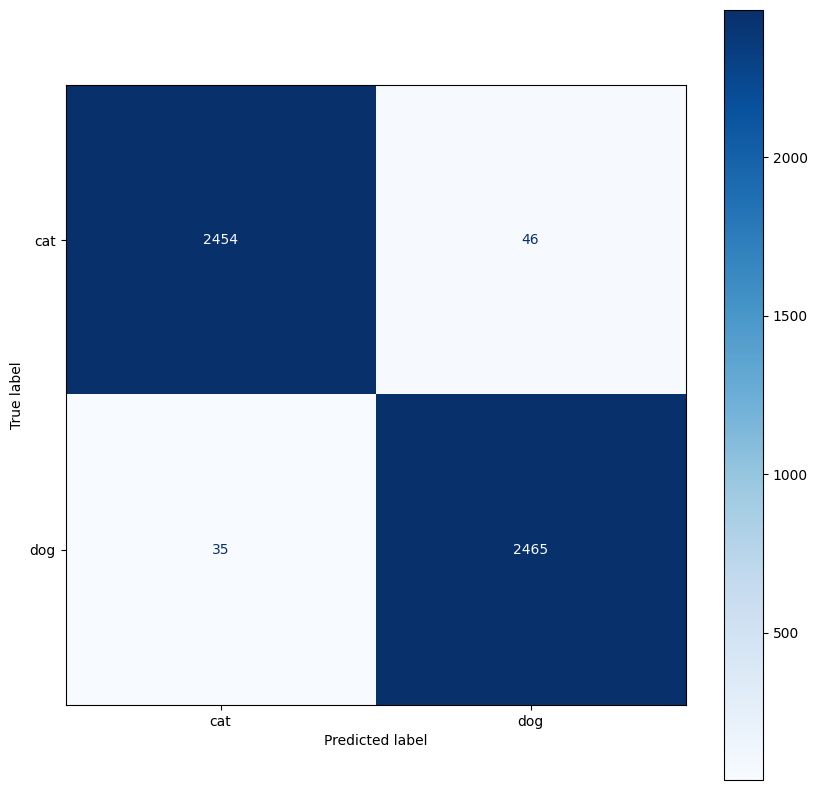

In [40]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10, 10))
cm = confusion_matrix(val_data['label'], val_data['pred'])

# disp = confusion_matrix(val_data['label'], val_data['val_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=labels.values())
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.show()